# Logistic Regression

In [1]:
# Logistic Regression
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

In [2]:
SEED = 38
np.random.seed(SEED)

In [3]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")
df = df.dropna()

In [4]:
target_col = "loan_status"
X = df.drop(columns=[target_col])
y = df[target_col]
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if X[c].dtype != "object"]
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numeric columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'empl_len', 'ppl_household']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [6]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [7]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    solver="liblinear"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

In [8]:
pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm  = confusion_matrix(y_test, y_pred)

print("\n=== Metrics (Test Set) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n=== Confusion Matrix ===")
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))


=== Metrics (Test Set) ===
Accuracy : 0.8894
Precision: 0.7589
Recall   : 0.7365
F1-score : 0.7475
ROC-AUC  : 0.9503

=== Confusion Matrix ===
[[6532  468]
 [ 527 1473]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9253    0.9331    0.9292      7000
           1     0.7589    0.7365    0.7475      2000

    accuracy                         0.8894      9000
   macro avg     0.8421    0.8348    0.8384      9000
weighted avg     0.8884    0.8894    0.8888      9000



In [10]:
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
coefs = pipe.named_steps["model"].coef_.ravel()

top_k = 10
top_pos_idx = np.argsort(coefs)[-top_k:][::-1] 
top_neg_idx = np.argsort(coefs)[:top_k]

print(f"\n=== Top {top_k} Positive Coefficients (push to approve=1) ===")
for i in top_pos_idx:
    print(f"{feature_names[i]:40s}  {coefs[i]: .4f}")

print(f"\n=== Top {top_k} Negative Coefficients (push to reject=0) ===")
for i in top_neg_idx:
    print(f"{feature_names[i]:40s}  {coefs[i]: .4f}")


=== Top 10 Positive Coefficients (push to approve=1) ===
previous_loan_defaults_on_file_No          3.1303
loan_percent_income                        1.3946
loan_int_rate                              1.0130
person_home_ownership_RENT                 0.3484
loan_intent_DEBTCONSOLIDATION              0.2133
loan_intent_HOMEIMPROVEMENT                0.1996
person_age                                 0.1726
person_income                              0.0535
ppl_household                             -0.0013
cb_person_cred_hist_length                -0.0298

=== Top 10 Negative Coefficients (push to reject=0) ===
previous_loan_defaults_on_file_Yes        -5.1205
person_home_ownership_OWN                 -1.8856
loan_intent_VENTURE                       -1.0242
person_gender_female                      -1.0013
person_gender_male                        -0.9889
loan_intent_EDUCATION                     -0.7052
loan_amnt                                 -0.6511
loan_intent_PERSONAL               

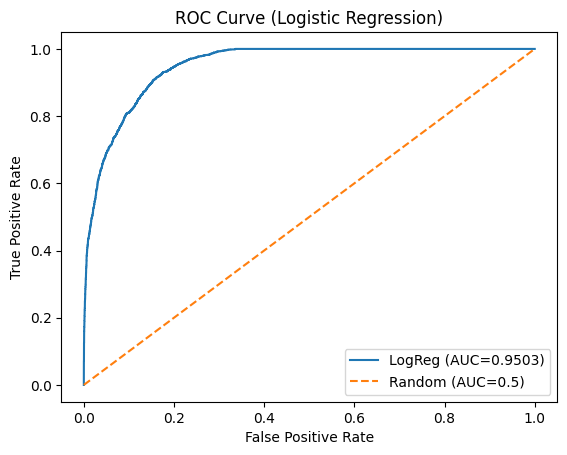

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

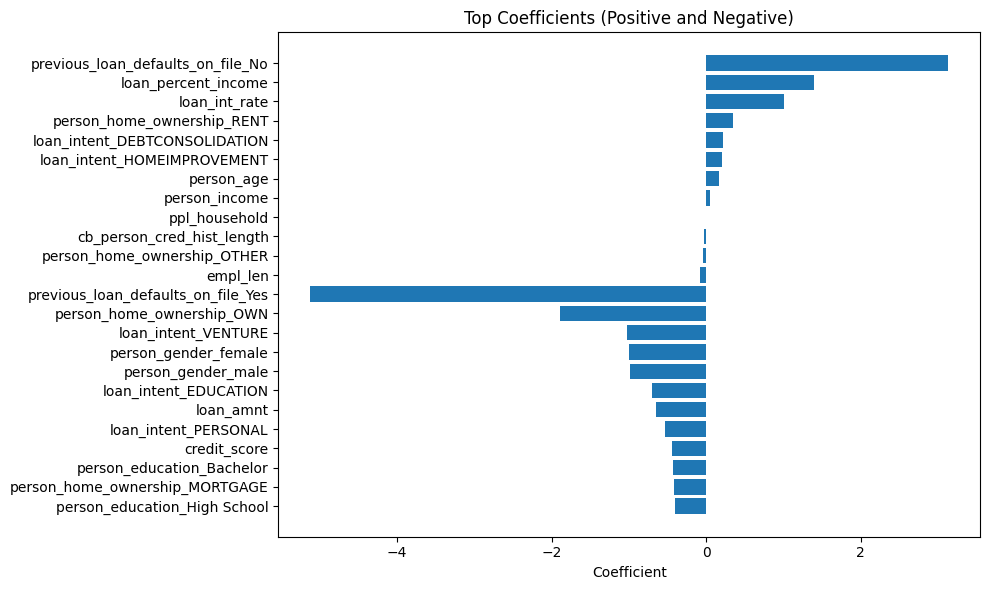

In [12]:
import matplotlib.pyplot as plt

preprocess = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]

cat_cols = preprocess.transformers_[1][2]  
num_cols = preprocess.transformers_[0][2]  

ohe = preprocess.named_transformers_["cat"]
feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

coefs = model.coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs}).sort_values("coef", ascending=False)

top_k = 12
top_pos = coef_df.head(top_k)
top_neg = coef_df.tail(top_k).sort_values("coef", ascending=True)

plot_df = pd.concat([top_pos, top_neg], axis=0)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["coef"])
plt.xlabel("Coefficient")
plt.title("Top Coefficients (Positive and Negative)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

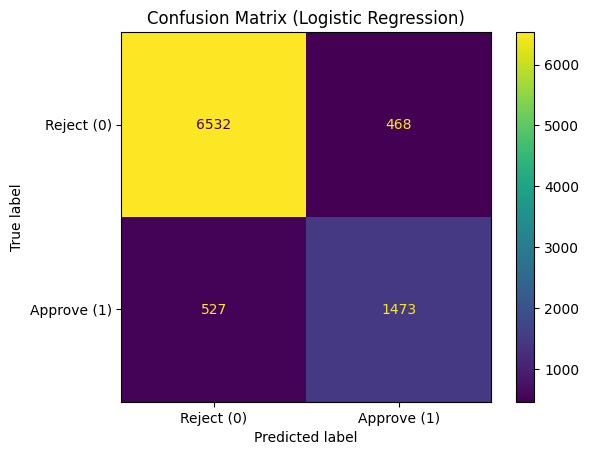

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Reject (0)", "Approve (1)"])

disp.plot(values_format="d")  
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

In [14]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")
df = df.dropna()

X = df.drop(columns=["loan_status"])
y = df["loan_status"].astype(int)

In [15]:
# Dummy variables for categoricals
X_enc = pd.get_dummies(X, drop_first=True)   

In [16]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=SEED, stratify=y
)

In [17]:
# Scaling (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [18]:
# k-fold CV setup
cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
Cs = [0.1, 1, 10]

def tune_C(penalty):
    scores = {}
    for C in Cs:
        model = LogisticRegression(
            penalty=penalty, solver="liblinear", C=C,
            max_iter=1000, random_state=SEED
        )
        cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring="f1", n_jobs=1)
        scores[C] = (cv_scores.mean(), cv_scores.std())
    best_C = max(scores, key=lambda c: scores[c][0])

    best_model = LogisticRegression(
        penalty=penalty, solver="liblinear", C=best_C,
        max_iter=1000, random_state=SEED
    ).fit(X_train_sc, y_train)

    return best_C, scores, best_model

def evaluate(model):
    yhat_train = model.predict(X_train_sc)
    yhat_test = model.predict(X_test_sc)
    return {
        "train_acc": accuracy_score(y_train, yhat_train),
        "test_acc": accuracy_score(y_test, yhat_test),
        "train_f1": f1_score(y_train, yhat_train),
        "test_f1": f1_score(y_test, yhat_test),
        "cm": confusion_matrix(y_test, yhat_test)
    }

# Model A: L2
bestC_l2, cv_l2, model_l2 = tune_C("l2")
res_l2 = evaluate(model_l2)

# Model B: L1
bestC_l1, cv_l1, model_l1 = tune_C("l1")
res_l1 = evaluate(model_l1)

print("L2 best C:", bestC_l2, "CV F1 (mean,std):", cv_l2[bestC_l2], "Test:", res_l2)
print("L1 best C:", bestC_l1, "CV F1 (mean,std):", cv_l1[bestC_l1], "Test:", res_l1)

L2 best C: 1 CV F1 (mean,std): (np.float64(0.7669268690007813), np.float64(0.005065632802157169)) Test: {'train_acc': 0.8988611111111111, 'test_acc': 0.8892222222222222, 'train_f1': 0.7686050206545917, 'test_f1': 0.7471468425057063, 'cm': array([[6530,  470],
       [ 527, 1473]])}
L1 best C: 10 CV F1 (mean,std): (np.float64(0.7669078400503627), np.float64(0.005114014702337051)) Test: {'train_acc': 0.8988333333333334, 'test_acc': 0.8892222222222222, 'train_f1': 0.7685267573407907, 'test_f1': 0.7471468425057063, 'cm': array([[6530,  470],
       [ 527, 1473]])}


In [19]:
# Hyperparameter tuning (manual grid via CV)
#    - Only tune what we used/covered: C and penalty (L1/L2)
# =========================================================
Cs = [0.01, 0.1, 1, 10, 100]  
def cv_tune_logreg(penalty: str, C_grid, cv_obj):
    """
    Hyperparameter tuning for Logistic Regression using k-fold CV.
    Select best C by mean CV F1 score.
    """
    results = []
    for C in C_grid:
        model = LogisticRegression(
            penalty=penalty,
            solver="liblinear",     # supports L1/L2
            C=C,
            max_iter=1000,
            random_state=SEED
        )

        # CV F1
        f1_scores = cross_val_score(model, X_train_sc, y_train, cv=cv_obj, scoring="f1", n_jobs=1)
        # CV Accuracy (extra metric requested)
        acc_scores = cross_val_score(model, X_train_sc, y_train, cv=cv_obj, scoring="accuracy", n_jobs=1)

        results.append({
            "penalty": penalty,
            "C": C,
            "cv_f1_mean": f1_scores.mean(),
            "cv_f1_std": f1_scores.std(),
            "cv_acc_mean": acc_scores.mean(),
            "cv_acc_std": acc_scores.std()
        })

    results_df = pd.DataFrame(results).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)
    best_C = results_df.loc[0, "C"]

    best_model = LogisticRegression(
        penalty=penalty,
        solver="liblinear",
        C=best_C,
        max_iter=1000,
        random_state=SEED
    ).fit(X_train_sc, y_train)

    return results_df, best_model

def evaluate_model(model, name="Model"):
    """
    Evaluate on train and test using Accuracy, F1, and confusion matrix on test.
    """
    yhat_train = model.predict(X_train_sc)
    yhat_test = model.predict(X_test_sc)

    out = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, yhat_train),
        "test_accuracy": accuracy_score(y_test, yhat_test),
        "train_f1": f1_score(y_train, yhat_train),
        "test_f1": f1_score(y_test, yhat_test),
        "test_confusion_matrix": confusion_matrix(y_test, yhat_test)
    }
    return out

# -----------------------------
# Tune L2
# -----------------------------
tune_l2_df, best_l2_model = cv_tune_logreg("l2", Cs, cv)
l2_eval = evaluate_model(best_l2_model, name="LogReg(L2)")

# -----------------------------
# Tune L1
# -----------------------------
tune_l1_df, best_l1_model = cv_tune_logreg("l1", Cs, cv)
l1_eval = evaluate_model(best_l1_model, name="LogReg(L1)")

# =========================================================
# Print tuning tables & final evaluations
# =========================================================
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

print("\n==================== Hyperparameter Tuning Results (L2) ====================")
print(tune_l2_df)

print("\n==================== Hyperparameter Tuning Results (L1) ====================")
print(tune_l1_df)

print("\n==================== Final Evaluation (Best L2) ====================")
print(f"Best L2 C = {best_l2_model.C}")
print("Train Accuracy:", round(l2_eval["train_accuracy"], 5))
print("Test  Accuracy:", round(l2_eval["test_accuracy"], 5))
print("Train F1:", round(l2_eval["train_f1"], 5))
print("Test  F1:", round(l2_eval["test_f1"], 5))
print("Test Confusion Matrix:\n", l2_eval["test_confusion_matrix"])

print("\n==================== Final Evaluation (Best L1) ====================")
print(f"Best L1 C = {best_l1_model.C}")
print("Train Accuracy:", round(l1_eval["train_accuracy"], 5))
print("Test  Accuracy:", round(l1_eval["test_accuracy"], 5))
print("Train F1:", round(l1_eval["train_f1"], 5))
print("Test  F1:", round(l1_eval["test_f1"], 5))
print("Test Confusion Matrix:\n", l1_eval["test_confusion_matrix"])


==================== Hyperparameter Tuning Results (L2) ====================
  penalty       C  cv_f1_mean  cv_f1_std  cv_acc_mean  cv_acc_std
0      l2    1.00    0.766927   0.005066     0.898167    0.001929
1      l2  100.00    0.766908   0.005114     0.898139    0.001956
2      l2   10.00    0.766908   0.005114     0.898139    0.001956
3      l2    0.10    0.766880   0.004973     0.898222    0.001942
4      l2    0.01    0.764723   0.005805     0.897417    0.002416

==================== Hyperparameter Tuning Results (L1) ====================
  penalty       C  cv_f1_mean  cv_f1_std  cv_acc_mean  cv_acc_std
0      l1  100.00    0.766908   0.005114     0.898139    0.001956
1      l1   10.00    0.766908   0.005114     0.898139    0.001956
2      l1    1.00    0.766639   0.005423     0.898056    0.002035
3      l1    0.10    0.766449   0.005553     0.898028    0.002212
4      l1    0.01    0.761263   0.006559     0.896444    0.002753

==================== Final Evaluation (Best L2) ===

In [20]:
# Bias/Variance check using Learning Curve (for best model)
#    - We pick the better one by test_f1 (or by cv_f1_mean)
# =========================================================
final_model = best_l2_model if l2_eval["test_f1"] >= l1_eval["test_f1"] else best_l1_model
final_name = "LogReg(L2)" if final_model is best_l2_model else "LogReg(L1)"

train_sizes = np.linspace(0.1, 1.0, 5)

sizes_abs, train_scores, valid_scores = learning_curve(
    final_model,
    X_train_sc,
    y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1",
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

print("\n==================== Learning Curve (F1) ====================")
print("Using:", final_name, "| Best C =", final_model.C)
print("size_abs | train_f1_mean | valid_f1_mean")
for s, tr, va in zip(sizes_abs, train_mean, valid_mean):
    print(f"{s:7d} | {tr:.5f}      | {va:.5f}")


==================== Learning Curve (F1) ====================
Using: LogReg(L2) | Best C = 1.0
size_abs | train_f1_mean | valid_f1_mean
   2400 | 0.77146      | 0.74918
   7800 | 0.76171      | 0.76351
  13200 | 0.76515      | 0.76570
  18600 | 0.76535      | 0.76676
  24000 | 0.76876      | 0.76693


# RandomFroest

In [21]:
# RandomFroest
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, average_precision_score
)

RANDOM_SEED = 38

In [22]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")

In [23]:
y = df["loan_status"]
X = df.drop(columns=["loan_status"])

In [24]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numeric columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'empl_len', 'ppl_household']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

In [26]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),

        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
    ],
    remainder="drop"
)

In [27]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

In [28]:
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n=== Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))



=== Test Metrics ===
Accuracy : 0.9264
Precision: 0.8982
Recall   : 0.7545
F1-score : 0.8201
ROC-AUC  : 0.9713

Confusion Matrix:
[[6829  171]
 [ 491 1509]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9329    0.9756    0.9538      7000
           1     0.8982    0.7545    0.8201      2000

    accuracy                         0.9264      9000
   macro avg     0.9156    0.8650    0.8869      9000
weighted avg     0.9252    0.9264    0.9241      9000



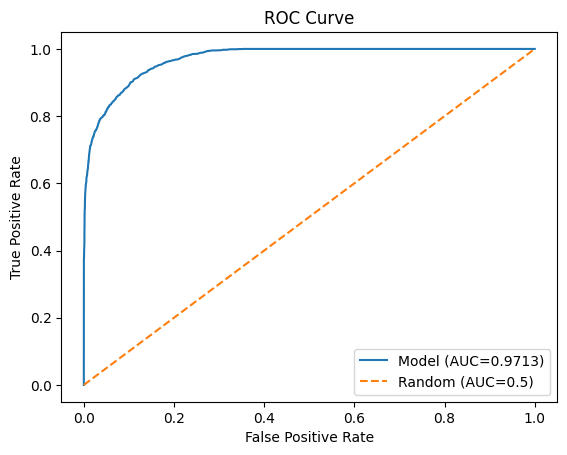

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Model (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np

In [32]:
cart = DecisionTreeClassifier(
    criterion="gini",       
    splitter="best",          
    max_depth=8,               
    min_samples_split=50,      
    min_samples_leaf=25,       
    random_state=RANDOM_SEED
)

cart_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("cart", cart)
])

In [33]:
cart_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('cart', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred_dt = cart_model.predict(X_test)
y_proba_dt = cart_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_dt)
pre = precision_score(y_test, y_pred_dt)
rec = recall_score(y_test, y_pred_dt)
f1  = f1_score(y_test, y_pred_dt)
auc = roc_auc_score(y_test, y_proba_dt)

print("\n=== CART Decision Tree Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, digits=4))


=== CART Decision Tree Test Metrics ===
Accuracy : 0.9183
Precision: 0.8799
Recall   : 0.7325
F1-score : 0.7995
ROC-AUC  : 0.9636

Confusion Matrix:
[[6800  200]
 [ 535 1465]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9271    0.9714    0.9487      7000
           1     0.8799    0.7325    0.7995      2000

    accuracy                         0.9183      9000
   macro avg     0.9035    0.8520    0.8741      9000
weighted avg     0.9166    0.9183    0.9156      9000



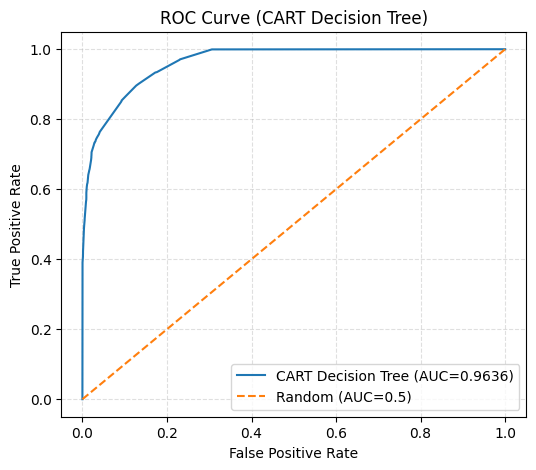

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_dt = cart_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
auc = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"CART Decision Tree (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CART Decision Tree)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [36]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")
df = df.dropna()
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

In [37]:
SEED = 38
np.random.seed(SEED)

In [38]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

def evaluate(pipe, X_te, y_te, thr=0.5):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba),
        "avg_precision": average_precision_score(y_te, proba),
        "confusion_matrix": confusion_matrix(y_te, pred),
    }

In [39]:
# Baselines
dt_base = Pipeline([("prep", preprocess),
                    ("model", DecisionTreeClassifier(random_state=SEED))])

rf_base = Pipeline([("prep", preprocess),
                    ("model", RandomForestClassifier(
                        random_state=SEED, n_estimators=120, n_jobs=1
                    ))])

dt_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

print("DT baseline:", evaluate(dt_base, X_test, y_test))
print("RF baseline:", evaluate(rf_base, X_test, y_test))

DT baseline: {'accuracy': 0.9003333333333333, 'precision': 0.769418661455789, 'recall': 0.7875, 'f1': 0.7783543365455893, 'roc_auc': 0.8600357142857143, 'avg_precision': 0.6531394181186561, 'confusion_matrix': array([[6528,  472],
       [ 425, 1575]])}
RF baseline: {'accuracy': 0.9247777777777778, 'precision': 0.8795180722891566, 'recall': 0.7665, 'f1': 0.8191290408763024, 'roc_auc': 0.9707127857142857, 'avg_precision': 0.9192784999178676, 'confusion_matrix': array([[6790,  210],
       [ 467, 1533]])}


In [40]:
# Cross-validation (Stratified K-fold)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {"roc_auc": "roc_auc", "f1": "f1"}

dt_cv = cross_validate(dt_base, X_train, y_train, cv=cv3, scoring=scoring,
                       return_train_score=True, n_jobs=1)
rf_cv = cross_validate(rf_base, X_train, y_train, cv=cv3, scoring=scoring,
                       return_train_score=True, n_jobs=1)

print("DT CV train/test ROC-AUC mean:",
      dt_cv["train_roc_auc"].mean(), dt_cv["test_roc_auc"].mean())
print("RF CV train/test ROC-AUC mean:",
      rf_cv["train_roc_auc"].mean(), rf_cv["test_roc_auc"].mean())

DT CV train/test ROC-AUC mean: 1.0 0.8539290530866906
RF CV train/test ROC-AUC mean: 1.0 0.9727752812417657


In [41]:
# Hyperparameter tuning: Decision Tree (GridSearchCV)
dt_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 8, None],
    "model__min_samples_leaf": [1, 10],
    "model__class_weight": [None, "balanced"],
}

dt_search = GridSearchCV(
    Pipeline([("prep", preprocess),
              ("model", DecisionTreeClassifier(random_state=SEED))]),
    param_grid=dt_grid,
    scoring="roc_auc",
    cv=cv3,
    n_jobs=1
)
dt_search.fit(X_train, y_train)
dt_best = dt_search.best_estimator_

print("DT best params:", dt_search.best_params_)
print("DT tuned test:", evaluate(dt_best, X_test, y_test))

DT best params: {'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 10}
DT tuned test: {'accuracy': 0.9157777777777778, 'precision': 0.8718562874251496, 'recall': 0.728, 'f1': 0.7934604904632152, 'roc_auc': 0.9636514285714286, 'avg_precision': 0.8891059556213976, 'confusion_matrix': array([[6786,  214],
       [ 544, 1456]])}


In [42]:
# Hyperparameter tuning: Random Forest (OOB evaluation)
candidates = [
    dict(n_estimators=120, max_depth=None, min_samples_leaf=1, max_features="sqrt", class_weight=None),
    dict(n_estimators=120, max_depth=20,   min_samples_leaf=1, max_features="sqrt", class_weight=None),
    dict(n_estimators=120, max_depth=None, min_samples_leaf=5, max_features="sqrt", class_weight=None),
    dict(n_estimators=120, max_depth=20,   min_samples_leaf=5, max_features="sqrt", class_weight="balanced"),
]

best_pipe, best_oob_auc = None, -1

for p in candidates:
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            random_state=42, n_jobs=1,
            bootstrap=True, oob_score=True,
            **p
        ))
    ])
    pipe.fit(X_train, y_train)
    oob_proba = pipe.named_steps["model"].oob_decision_function_[:, 1]
    oob_auc = roc_auc_score(y_train, oob_proba)

    if oob_auc > best_oob_auc:
        best_oob_auc = oob_auc
        best_pipe = pipe

print("RF best (by OOB AUC):", best_oob_auc)
print("RF tuned test:", evaluate(best_pipe, X_test, y_test))

RF best (by OOB AUC): 0.9730722187499998
RF tuned test: {'accuracy': 0.9244444444444444, 'precision': 0.8873239436619719, 'recall': 0.756, 'f1': 0.816414686825054, 'roc_auc': 0.9705260714285714, 'avg_precision': 0.9197192626793885, 'confusion_matrix': array([[6808,  192],
       [ 488, 1512]])}


In [43]:
# Feature importance (RF) 
ohe = best_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_names])

importances = best_pipe.named_steps["model"].feature_importances_
top_idx = np.argsort(importances)[::-1][:10]

print("Top-10 feature importances:")
for i in top_idx:
    print(feature_names[i], importances[i])

Top-10 feature importances:
loan_percent_income 0.16587789808750175
previous_loan_defaults_on_file_Yes 0.1655554235446614
previous_loan_defaults_on_file_No 0.15596323247337826
loan_int_rate 0.15208503798325623
person_income 0.10498703052728085
person_home_ownership_RENT 0.04729541439317638
loan_amnt 0.04146628934555504
credit_score 0.03342709016706172
person_home_ownership_MORTGAGE 0.02142345797450827
person_age 0.013149058758042339


# ANN

In [44]:
#ANN
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_curve, auc as sk_auc

import random

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve, auc, accuracy_score
)

SEED = 38
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [45]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")
df = df.dropna()
y = df["loan_status"].astype(int)
X = df.drop(columns=["loan_status"])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [47]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)


In [48]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,                    
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("ann", ann)
])

In [49]:
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('ann', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("=== ANN (MLP) Evaluation ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

=== ANN (MLP) Evaluation ===
Accuracy : 0.9068
Precision: 0.8129
Recall   : 0.7540
F1-score : 0.7824
ROC-AUC  : 0.9615

Confusion Matrix:
 [[6653  347]
 [ 492 1508]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9311    0.9504    0.9407      7000
           1     0.8129    0.7540    0.7824      2000

    accuracy                         0.9068      9000
   macro avg     0.8720    0.8522    0.8615      9000
weighted avg     0.9049    0.9068    0.9055      9000



In [51]:
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")
X = df.drop(columns=["loan_status"])
y = df["loan_status"].astype(int)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

In [53]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


In [54]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",      
    solver="adam",          
    alpha=1e-4,                
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED
)

model = Pipeline([("prep", preprocess), ("ann", ann)])
model.fit(X_train, y_train)


,steps,"[('prep', ...), ('ann', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
y_prob = model.predict_proba(X_test)[:, 1]

In [56]:
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print("Accuracy:", acc)
print("ROC-AUC :", auc)
print("Precision/Recall/F1:", prec, rec, f1)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9067777777777778
ROC-AUC : 0.9614865714285714
Precision/Recall/F1: 0.8129380053908356 0.754 0.7823605706874189
Confusion matrix:
 [[6653  347]
 [ 492 1508]]


In [57]:
import numpy as np
from sklearn.metrics import f1_score

ths = np.linspace(0.05, 0.95, 19)
best = (None, -1)
for t in ths:
    pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, pred)
    if f1 > best[1]:
        best = (t, f1)
print("Best threshold (by F1):", best[0], "Best F1:", best[1])

Best threshold (by F1): 0.39999999999999997 Best F1: 0.7850146914789422


In [58]:
SEED_VALUE = 38
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [59]:
# 1. Data loading
df = pd.read_csv("F:/桌面/UCL FT/COMP0198 Machine Learning with Applications in Finance/course wrok/Dataset - 2526.csv")

# Missing value handling
df = df.dropna()

# Feature engineering and encoding
X_raw = df.drop('loan_status', axis=1)
y = df['loan_status']
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Data splitting
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=SEED_VALUE, stratify=y
)

# Feature standardization (for compatibility with SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# Validation set split from the training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train_full, test_size=0.2, random_state=SEED_VALUE
)

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (28800, 24)
Validation shape: (7200, 24)
Testing shape: (9000, 24)


In [60]:
# Building the ANN Model (Based on Week 7)
def build_ann_model(n_neurons=30, learning_rate=0.01, input_shape=[X_train.shape[1]]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    
    # Hidden layers (ReLU activation)
    model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(n_neurons, activation="relu"))
    
    # Output layer (Sigmoid for binary classification)
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    
    # Compile the model using SGD optimizer
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    
    return model

In [61]:
# 3) Hyperparameter Tuning
# ==========================================

param_grid = [
    {'n_neurons': 16, 'learning_rate': 0.01},
    {'n_neurons': 32, 'learning_rate': 0.01},
    {'n_neurons': 64, 'learning_rate': 0.01},
    {'n_neurons': 32, 'learning_rate': 0.1},
]

best_auc = 0
best_params = {}
best_model = None
best_history = None

print("\nStarting Hyperparameter Tuning...")

for params in param_grid:
    print(f"Testing: {params}")
    model = build_ann_model(n_neurons=params['n_neurons'], learning_rate=params['learning_rate'])
    history = model.fit(
        X_train, y_train, 
        epochs=30, 
        batch_size=32, 
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    # Validation performance evaluation
    y_val_pred = model.predict(X_val).ravel()
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred)
    val_auc = sk_auc(fpr_val, tpr_val)
    
    print(f"  -> Validation AUC: {val_auc:.4f}")
    
    if val_auc > best_auc:
        best_auc = val_auc
        best_params = params
        best_model = model
        best_history = history

print(f"\nBest Parameters found: {best_params}")
print(f"Best Validation Accuracy: {best_auc:.4f}")


Starting Hyperparameter Tuning...
Testing: {'n_neurons': 16, 'learning_rate': 0.01}


F:\Python\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
  -> Validation AUC: 0.9660
Testing: {'n_neurons': 32, 'learning_rate': 0.01}


F:\Python\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
  -> Validation AUC: 0.9684
Testing: {'n_neurons': 64, 'learning_rate': 0.01}


F:\Python\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step
  -> Validation AUC: 0.9685
Testing: {'n_neurons': 32, 'learning_rate': 0.1}


F:\Python\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step
  -> Validation AUC: 0.9697

Best Parameters found: {'n_neurons': 32, 'learning_rate': 0.1}
Best Validation Accuracy: 0.9697


282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step

Final Test Accuracy: 0.2222
Final AUC Score: 0.5000


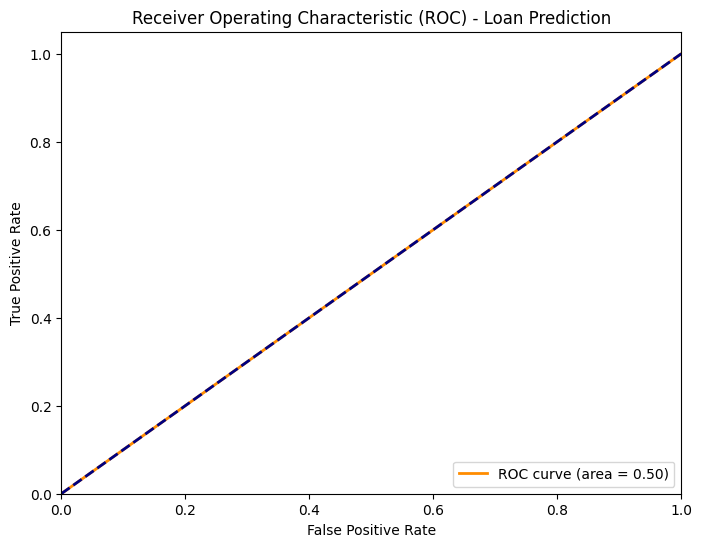

In [62]:
# Final Evaluation
# Use the best model to make predictions on the test set
y_pred_proba = best_model.predict(X_test).ravel()
y_pred_class = (y_pred_proba > 0.5).astype(int)

# 1. Accuracy
test_acc = accuracy_score(y_test, y_pred_class)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# 2. ROC Curve & AUC (Week 4 Section 1.4)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = sk_auc(fpr, tpr)
print(f"Final AUC Score: {roc_auc:.4f}")

# Plot ROC curve  (Week 4 1.4 Visualizing)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Loan Prediction')
plt.legend(loc="lower right")
plt.show()

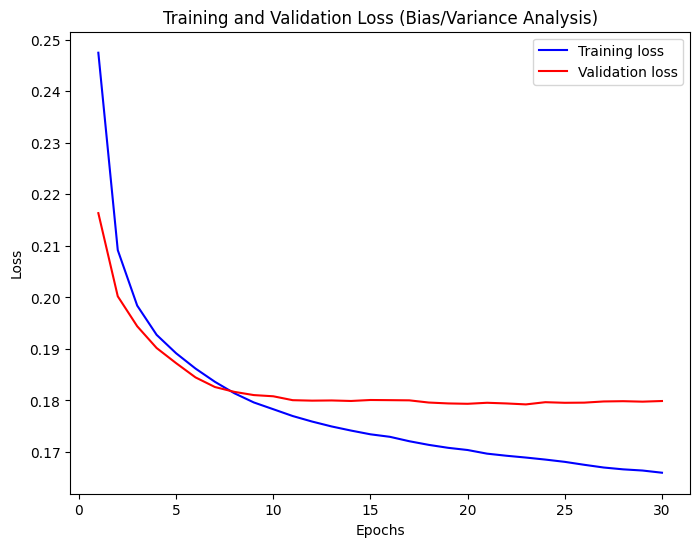

In [63]:
# Bias vs Variance Analysis
# Retrieve training history from the best model
history = best_model.history 

# Extract loss values 
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss (Bias/Variance Analysis)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()